In [20]:
import pandas as pd
import numpy as np
import sklearn
import xgboost
import matplotlib.pyplot as plt
import seaborn as sns
import openai
import anthropic
from dotenv import load_dotenv
from google.generativeai.string_utils import prettyprint

print("✅ All imports work!")
print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost:      {xgboost.__version__}")
print(f"openai:       {openai.__version__}")
print(f"anthropic:    {anthropic.__version__}")

✅ All imports work!
pandas:       3.0.3
numpy:        2.4.5
scikit-learn: 1.8.0
xgboost:      3.2.0
openai:       2.37.0
anthropic:    0.102.0


/var/folders/fn/cxstqgfd5k7dm_wy6xrc_1hc0000gn/T/ipykernel_87624/3453845491.py:10: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  from google.generativeai.string_utils import prettyprint


In [21]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if (str(project_root) not in sys.path):
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_churn, load_housing, load_bank
from src.config import FIGURES_DIR

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("✅ Setup complete")

✅ Setup complete


In [22]:
X_churn, y_churn = load_churn()
X_housing, y_housing = load_housing()
X_bank, y_bank = load_bank()

datasets = {
    "Churn": (X_churn, y_churn),
    "Housing": (X_housing, y_housing),
    "Bank": (X_bank, y_bank),
}

✅ Churn loaded: 7043 rows × 19 features
   Class balance: 26.5% churned
   Dropped 6 cols with >40% missing
✅ Housing loaded: 2930 rows × 73 features
   Target range: $12,789 – $755,000
✅ Bank loaded: 41188 rows × 19 features
   Class balance: 11.3% subscribed


In [23]:
overview = []

for name, (X, y) in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": X.shape[0],
        "Columns": X.shape[1],
        "Numeric cols": X.select_dtypes(include=np.number).shape[1],
        "Categorical cols": X.select_dtypes(exclude=np.number).shape[1],
        "Missing values (total)": X.isnull().sum().sum(),
        "Target type": "Binary" if y.nunique() == 2 else "Continuous"
    })


pd.DataFrame(overview)

,Dataset,Rows,Columns,Numeric cols,Categorical cols,Missing values (total),Target type
0,Churn,7043,19,4,15,0,Binary
1,Housing,2930,73,36,37,1721,Continuous
2,Bank,41188,19,9,10,0,Binary


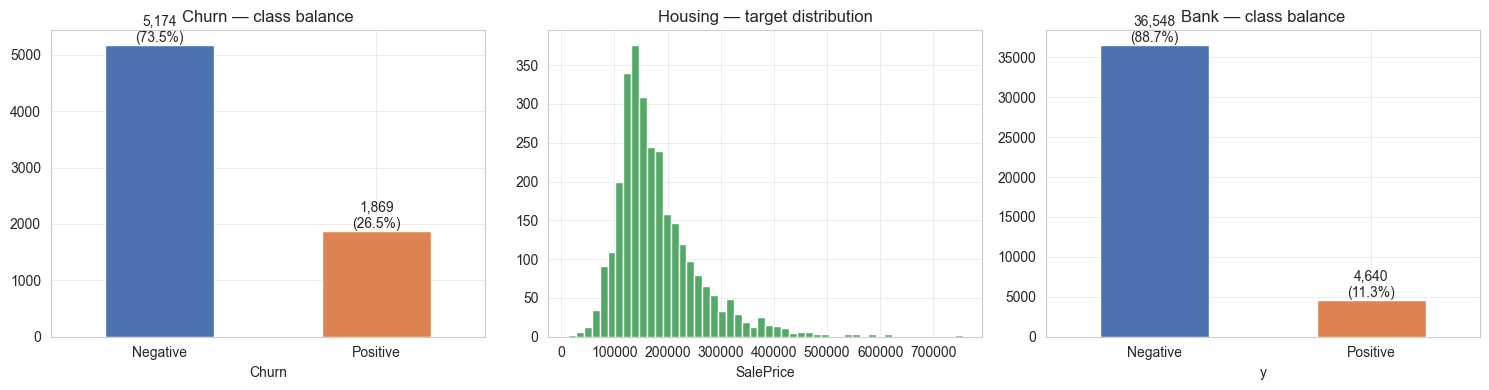

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (X, y)) in zip(axes, datasets.items()):
  if y.nunique() == 2:
      y.value_counts().plot.bar(ax=ax, color=["#4C72B0", "#DD8452"])
      ax.set_title(f"{name} — class balance")
      ax.set_xticklabels(["Negative", "Positive"], rotation=0)
      for i, v in enumerate(y.value_counts()):
          ax.text(i, v, f"{v:,}\n({v/len(y):.1%})", ha="center", va="bottom")
  else:
      ax.hist(y, bins=50, color="#55A868", edgecolor="white")
      ax.set_title(f"{name} — target distribution")
      ax.set_xlabel(y.name)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_target_distributions.png", bbox_inches="tight")
plt.show()

/var/folders/fn/cxstqgfd5k7dm_wy6xrc_1hc0000gn/T/ipykernel_87624/3078204558.py:16: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/fn/cxstqgfd5k7dm_wy6xrc_1hc0000gn/T/ipykernel_87624/3078204558.py:17: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "02_missing_values.png", bbox_inches="tight")
/Users/konstantinosevangelidis/PycharmProjects/llm-feature-engineering/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


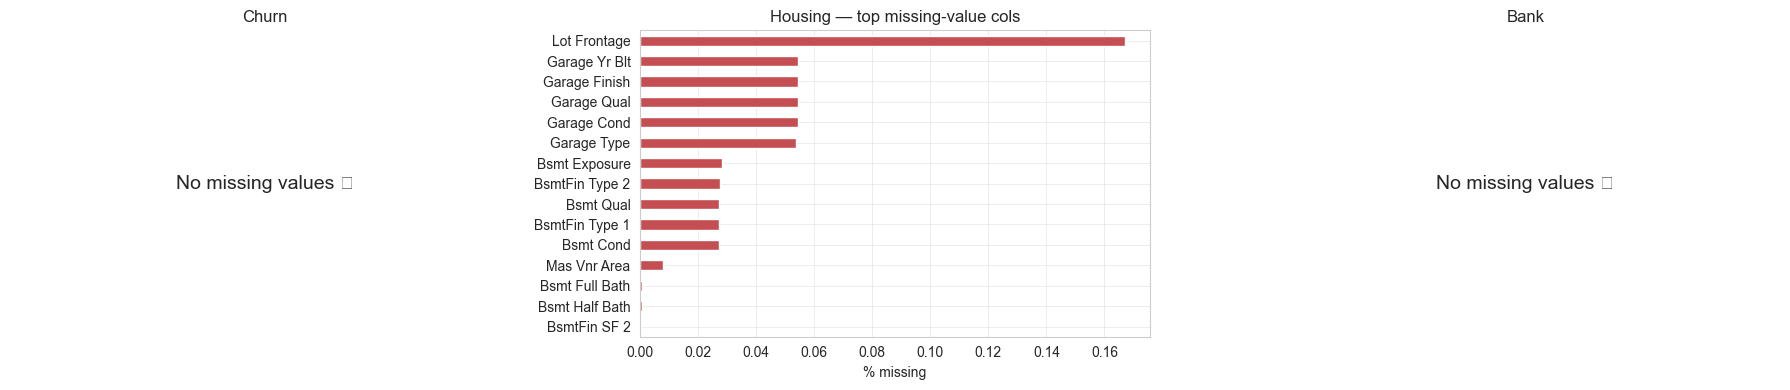

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (name, (X, _)) in zip(axes, datasets.items()):
  missing = X.isnull().mean().sort_values(ascending=False)
  missing = missing[missing > 0].head(15)
  if len(missing) == 0:
      ax.text(0.5, 0.5, "No missing values 🎉", ha="center", va="center", fontsize=14)
      ax.set_title(f"{name}")
      ax.axis("off")
  else:
      missing.plot.barh(ax=ax, color="#C44E52")
      ax.set_title(f"{name} — top missing-value cols")
      ax.set_xlabel("% missing")
      ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_missing_values.png", bbox_inches="tight")
plt.show()

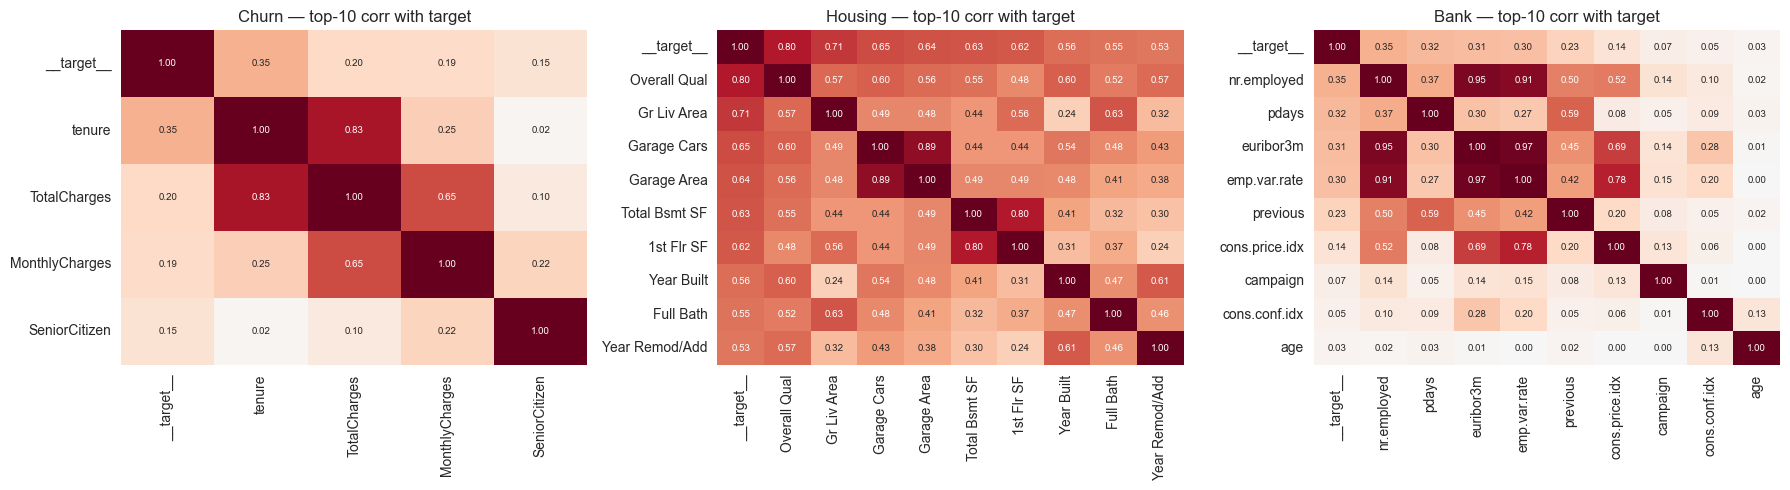

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (X, y)) in zip(axes, datasets.items()):
  df_with_target = X.select_dtypes(include=np.number).copy()
  df_with_target["__target__"] = y.values
  corr = df_with_target.corr().abs()

  top_features = corr["__target__"].sort_values(ascending=False).head(10).index
  sns.heatmap(corr.loc[top_features, top_features], cmap="RdBu_r", center=0,
              ax=ax, annot=True, fmt=".2f", cbar=False, annot_kws={"size": 7})
  ax.set_title(f"{name} — top-10 corr with target")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_correlations.png", bbox_inches="tight")
plt.show()

In [27]:
for name, (X, _) in datasets.items():
  print(f"\n{'='*70}")
  print(f"{name} — {X.shape[1]} columns")
  print('='*70)
  print(", ".join(X.columns.tolist()))


Churn — 19 columns
gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges

Housing — 73 columns
MS SubClass, MS Zoning, Lot Frontage, Lot Area, Street, Lot Shape, Land Contour, Utilities, Lot Config, Land Slope, Neighborhood, Condition 1, Condition 2, Bldg Type, House Style, Overall Qual, Overall Cond, Year Built, Year Remod/Add, Roof Style, Roof Matl, Exterior 1st, Exterior 2nd, Mas Vnr Area, Exter Qual, Exter Cond, Foundation, Bsmt Qual, Bsmt Cond, Bsmt Exposure, BsmtFin Type 1, BsmtFin SF 1, BsmtFin Type 2, BsmtFin SF 2, Bsmt Unf SF, Total Bsmt SF, Heating, Heating QC, Central Air, Electrical, 1st Flr SF, 2nd Flr SF, Low Qual Fin SF, Gr Liv Area, Bsmt Full Bath, Bsmt Half Bath, Full Bath, Half Bath, Bedroom AbvGr, Kitchen AbvGr, Kitchen Qual, TotRms AbvGrd, Functional, Fireplaces

In [29]:
from src.llm_client import LLMClient
from src.prompts import build_zero_shot_prompt, DATASET_CONFIG

# Build a prompt for churn
cfg = DATASET_CONFIG["churn"]
prompt = build_zero_shot_prompt(
    dataset_name=cfg["display_name"],
    task=cfg["task"],
    target=cfg["target"],
    columns=list(X_churn.columns),
)
print("Prompt first 500 chars:\n")
print(prompt[:500] + "...\n")

# Ask GPT-4o-mini
llm = LLMClient("gpt-4o-mini")
features = llm.suggest_features(
    prompt=prompt,
    dataset_name="churn",
    prompt_variant="zero_shot"
)

print("\n🎉 LLM-suggested features:\n")
for i, f in enumerate(features, 1):
    print(f"{i}. {f['name']}")
    print(f"   formula:   {f['formula']}")
    print(f"   rationale: {f['rationale']}\n")



Prompt first 500 chars:

You are a senior data scientist working on a binary classification problem.

Dataset: Telco Customer Churn
Target variable: Churn (whether the customer left)
Available columns: gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges

Suggest exactly 7 new engineered features that could improve ...


🎉 LLM-suggested features:

1. is_senior_partner
   formula:   (SeniorCitizen == 1) & (Partner == 'Yes')
   rationale: This feature captures the interaction between being a senior citizen and having a partner, which may influence churn behavior.

2. monthly_charge_to_tenure_ratio
   formula:   MonthlyCharges / (tenure + 1).clip(lower=1)
   rationale: This ratio helps to understand how monthly charges relate to the duration of service, potentially indicating value pe